# Cliff Walking: Q-learning vs SARSA

This notebook implements the classic **cliff-walking** reinforcement learning example.

It includes:

- a self-contained cliff-walking environment
- **Q-learning**
- **SARSA**
- policy visualization with arrows
- reward curves
- cliff-fall statistics

## Learning objective

This example is designed to show the difference between:

- **Q-learning**: off-policy TD control
- **SARSA**: on-policy TD control

In cliff walking, both algorithms face the same environment, but they often learn **different behaviors**:

- **Q-learning** tends to learn the shortest path close to the cliff
- **SARSA** often learns a safer path because it accounts for the actual exploratory policy during learning


## 1. Imports

The notebook uses only standard Python plus `numpy` and `matplotlib`.


In [1]:
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt


## 2. Environment definition

We use the canonical cliff-walking grid:

- grid size: **4 × 12**
- start: **bottom-left**
- goal: **bottom-right**
- cliff: bottom-row cells between start and goal

### Rewards

- normal step: **-1**
- stepping into cliff: **-100** and reset to start
- reaching goal: episode ends


In [2]:
Action = int
State = Tuple[int, int]

UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
ACTIONS = [UP, RIGHT, DOWN, LEFT]
ACTION_NAMES = {
    UP: "↑",
    RIGHT: "→",
    DOWN: "↓",
    LEFT: "←",
}


@dataclass
class StepResult:
    next_state: State
    reward: float
    done: bool
    fell_off_cliff: bool


class CliffWalkingEnv:
    def __init__(self, rows: int = 4, cols: int = 12):
        self.rows = rows
        self.cols = cols
        self.start_state = (rows - 1, 0)
        self.goal_state = (rows - 1, cols - 1)
        self.cliff_cells = {(rows - 1, c) for c in range(1, cols - 1)}
        self.state = self.start_state

    def reset(self) -> State:
        self.state = self.start_state
        return self.state

    def in_bounds(self, r: int, c: int) -> bool:
        return 0 <= r < self.rows and 0 <= c < self.cols

    def is_cliff(self, state: State) -> bool:
        return state in self.cliff_cells

    def step(self, action: Action) -> StepResult:
        r, c = self.state

        if action == UP:
            nr, nc = r - 1, c
        elif action == RIGHT:
            nr, nc = r, c + 1
        elif action == DOWN:
            nr, nc = r + 1, c
        elif action == LEFT:
            nr, nc = r, c - 1
        else:
            raise ValueError(f"Unknown action: {action}")

        if not self.in_bounds(nr, nc):
            nr, nc = r, c

        candidate = (nr, nc)

        if self.is_cliff(candidate):
            self.state = self.start_state
            return StepResult(
                next_state=self.start_state,
                reward=-100.0,
                done=False,
                fell_off_cliff=True,
            )

        if candidate == self.goal_state:
            self.state = candidate
            return StepResult(
                next_state=candidate,
                reward=-1.0,
                done=True,
                fell_off_cliff=False,
            )

        self.state = candidate
        return StepResult(
            next_state=candidate,
            reward=-1.0,
            done=False,
            fell_off_cliff=False,
        )

    def all_states(self) -> List[State]:
        return [(r, c) for r in range(self.rows) for c in range(self.cols)]


## 3. Q-table helpers and epsilon-greedy policy

We store action values in a NumPy array of shape:

`(rows, cols, 4)`

where the last dimension corresponds to:

- `0 = up`
- `1 = right`
- `2 = down`
- `3 = left`


In [3]:
def make_q_table(env: CliffWalkingEnv) -> np.ndarray:
    return np.zeros((env.rows, env.cols, len(ACTIONS)), dtype=float)


def greedy_action(Q: np.ndarray, state: State) -> Action:
    r, c = state
    values = Q[r, c]
    max_value = np.max(values)
    best_actions = [a for a, v in enumerate(values) if np.isclose(v, max_value)]
    return random.choice(best_actions)


def epsilon_greedy_action(Q: np.ndarray, state: State, epsilon: float) -> Action:
    if random.random() < epsilon:
        return random.choice(ACTIONS)
    return greedy_action(Q, state)


## 4. Training algorithms

We implement both algorithms with the same interface and collect:

- learned `Q`
- episode returns
- episode lengths
- cliff falls per episode


In [4]:
def train_q_learning(
    env: CliffWalkingEnv,
    episodes: int = 500,
    alpha: float = 0.5,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    max_steps_per_episode: int = 1000,
    seed: int = 42,
):
    random.seed(seed)
    np.random.seed(seed)

    Q = make_q_table(env)
    episode_returns = []
    episode_lengths = []
    cliff_falls = []

    for _ in range(episodes):
        state = env.reset()
        total_reward = 0.0
        falls = 0
        steps = 0
        done = False

        while not done and steps < max_steps_per_episode:
            action = epsilon_greedy_action(Q, state, epsilon)
            result = env.step(action)

            r, c = state
            nr, nc = result.next_state

            td_target = result.reward + gamma * np.max(Q[nr, nc]) * (0.0 if result.done else 1.0)
            td_error = td_target - Q[r, c, action]
            Q[r, c, action] += alpha * td_error

            state = result.next_state
            total_reward += result.reward
            falls += int(result.fell_off_cliff)
            steps += 1
            done = result.done

        episode_returns.append(total_reward)
        episode_lengths.append(steps)
        cliff_falls.append(falls)

    return {
        "Q": Q,
        "episode_returns": np.array(episode_returns, dtype=float),
        "episode_lengths": np.array(episode_lengths, dtype=int),
        "cliff_falls": np.array(cliff_falls, dtype=int),
    }


def train_sarsa(
    env: CliffWalkingEnv,
    episodes: int = 500,
    alpha: float = 0.5,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    max_steps_per_episode: int = 1000,
    seed: int = 42,
):
    random.seed(seed)
    np.random.seed(seed)

    Q = make_q_table(env)
    episode_returns = []
    episode_lengths = []
    cliff_falls = []

    for _ in range(episodes):
        state = env.reset()
        action = epsilon_greedy_action(Q, state, epsilon)
        total_reward = 0.0
        falls = 0
        steps = 0
        done = False

        while not done and steps < max_steps_per_episode:
            result = env.step(action)

            r, c = state
            nr, nc = result.next_state

            if result.done:
                td_target = result.reward
                next_action = None
            else:
                next_action = epsilon_greedy_action(Q, result.next_state, epsilon)
                td_target = result.reward + gamma * Q[nr, nc, next_action]

            td_error = td_target - Q[r, c, action]
            Q[r, c, action] += alpha * td_error

            state = result.next_state
            action = next_action if next_action is not None else action
            total_reward += result.reward
            falls += int(result.fell_off_cliff)
            steps += 1
            done = result.done

        episode_returns.append(total_reward)
        episode_lengths.append(steps)
        cliff_falls.append(falls)

    return {
        "Q": Q,
        "episode_returns": np.array(episode_returns, dtype=float),
        "episode_lengths": np.array(episode_lengths, dtype=int),
        "cliff_falls": np.array(cliff_falls, dtype=int),
    }


## 5. Visualization helpers

We create:

1. a **policy plot** with directional arrows
2. reward curves
3. cliff-fall curves
4. optional printed policy view


In [5]:
def extract_greedy_policy(env: CliffWalkingEnv, Q: np.ndarray) -> Dict[State, str]:
    policy = {}
    for state in env.all_states():
        if state == env.goal_state:
            policy[state] = "G"
        elif state == env.start_state:
            policy[state] = "S"
        elif env.is_cliff(state):
            policy[state] = "C"
        else:
            best_action = greedy_action(Q, state)
            policy[state] = ACTION_NAMES[best_action]
    return policy


def print_policy(env: CliffWalkingEnv, Q: np.ndarray):
    policy = extract_greedy_policy(env, Q)
    for r in range(env.rows):
        row = []
        for c in range(env.cols):
            row.append(f"{policy[(r, c)]:>2}")
        print(" ".join(row))


def moving_average(x: np.ndarray, window: int = 20) -> np.ndarray:
    if window <= 1:
        return x.copy()
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - window + 1)
        out[i] = np.mean(x[start:i+1])
    return out


In [6]:
def plot_policy(env: CliffWalkingEnv, Q: np.ndarray, title: str = "Policy"):
    policy = extract_greedy_policy(env, Q)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_xlim(0, env.cols)
    ax.set_ylim(0, env.rows)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    for r in range(env.rows):
        for c in range(env.cols):
            facecolor = "white"
            if (r, c) == env.start_state:
                facecolor = "#d9ead3"
            elif (r, c) == env.goal_state:
                facecolor = "#cfe2f3"
            elif env.is_cliff((r, c)):
                facecolor = "#f4cccc"

            rect = plt.Rectangle((c, r), 1, 1, fill=True, edgecolor="black", facecolor=facecolor)
            ax.add_patch(rect)

            label = policy[(r, c)]
            ax.text(c + 0.5, r + 0.5, label, ha="center", va="center", fontsize=18)

    ax.set_xticks(np.arange(env.cols + 1))
    ax.set_yticks(np.arange(env.rows + 1))
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    plt.show()


def plot_training_curves(q_results: dict, sarsa_results: dict, window: int = 20):
    episodes_q = np.arange(1, len(q_results["episode_returns"]) + 1)
    episodes_s = np.arange(1, len(sarsa_results["episode_returns"]) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(episodes_q, q_results["episode_returns"], alpha=0.35, label="Q-learning return")
    plt.plot(episodes_q, moving_average(q_results["episode_returns"], window), linewidth=2, label=f"Q-learning MA({window})")
    plt.plot(episodes_s, sarsa_results["episode_returns"], alpha=0.35, label="SARSA return")
    plt.plot(episodes_s, moving_average(sarsa_results["episode_returns"], window), linewidth=2, label=f"SARSA MA({window})")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Episode returns")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(episodes_q, q_results["cliff_falls"], alpha=0.4, label="Q-learning cliff falls")
    plt.plot(episodes_q, moving_average(q_results["cliff_falls"], window), linewidth=2, label=f"Q-learning MA({window})")
    plt.plot(episodes_s, sarsa_results["cliff_falls"], alpha=0.4, label="SARSA cliff falls")
    plt.plot(episodes_s, moving_average(sarsa_results["cliff_falls"], window), linewidth=2, label=f"SARSA MA({window})")
    plt.xlabel("Episode")
    plt.ylabel("Number of cliff falls")
    plt.title("Cliff-fall statistics")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(episodes_q, q_results["episode_lengths"], alpha=0.4, label="Q-learning episode length")
    plt.plot(episodes_q, moving_average(q_results["episode_lengths"], window), linewidth=2, label=f"Q-learning MA({window})")
    plt.plot(episodes_s, sarsa_results["episode_lengths"], alpha=0.4, label="SARSA episode length")
    plt.plot(episodes_s, moving_average(sarsa_results["episode_lengths"], window), linewidth=2, label=f"SARSA MA({window})")
    plt.xlabel("Episode")
    plt.ylabel("Steps per episode")
    plt.title("Episode lengths")
    plt.legend()
    plt.show()


## 6. Run the experiment

The parameters below are reasonable teaching defaults.

You can increase the number of episodes if you want cleaner convergence.


In [7]:
env = CliffWalkingEnv()

episodes = 500
alpha = 0.5
gamma = 1.0
epsilon = 0.1
seed = 2026

q_results = train_q_learning(
    env=env,
    episodes=episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    seed=seed,
)

sarsa_results = train_sarsa(
    env=env,
    episodes=episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    seed=seed,
)

print("Training complete.")


Training complete.


## 7. Compare learned policies

The key expectation is:

- **Q-learning** often learns a path hugging the cliff
- **SARSA** often learns a safer route farther from the cliff


In [8]:
print("Q-learning policy:")
print_policy(env, q_results["Q"])

print("\nSARSA policy:")
print_policy(env, sarsa_results["Q"])


Q-learning policy:
 ↓  ←  →  →  →  →  →  →  →  →  →  ↓
 ↓  ↓  →  ↓  →  →  →  ↓  →  ↓  →  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 S  C  C  C  C  C  C  C  C  C  C  G

SARSA policy:
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  →  →  →  →  ↑  ↑  ↑  ↓  ↑  →  ↓
 →  →  ↑  ↑  ↑  ↑  ↑  ↑  →  →  →  ↓
 S  C  C  C  C  C  C  C  C  C  C  G


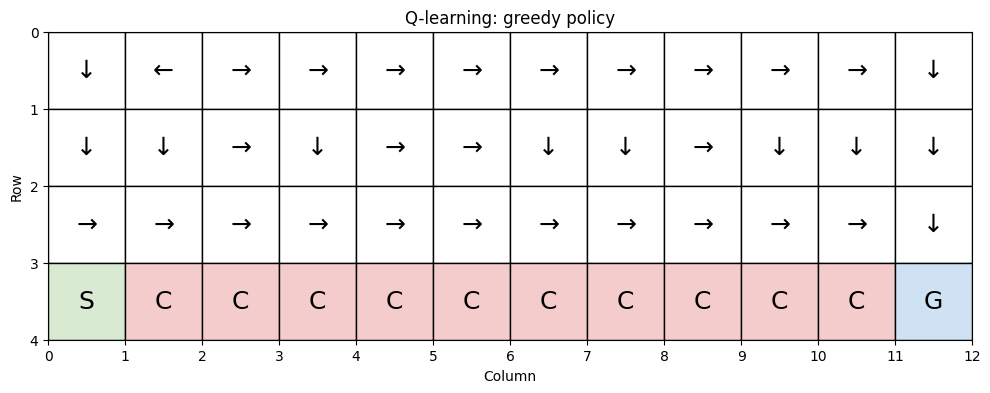

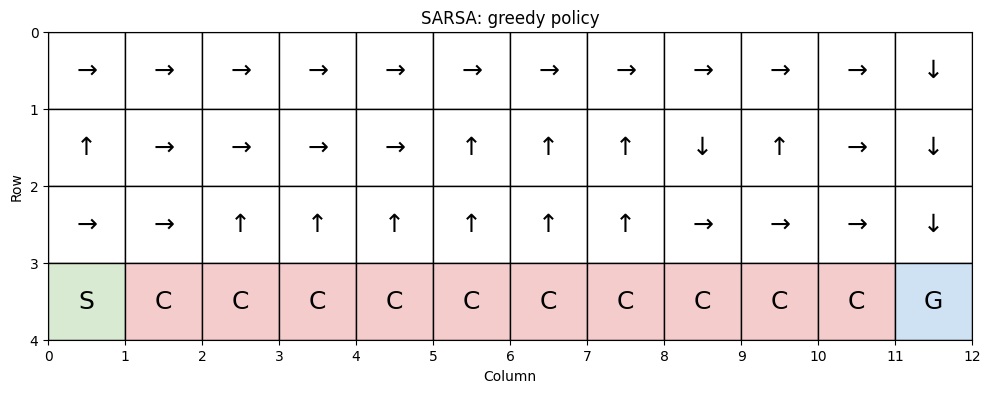

In [9]:
plot_policy(env, q_results["Q"], title="Q-learning: greedy policy")
plot_policy(env, sarsa_results["Q"], title="SARSA: greedy policy")


## 8. Reward curves and cliff-fall statistics

These plots show not only the final policy but also the **training behavior** of the two algorithms.


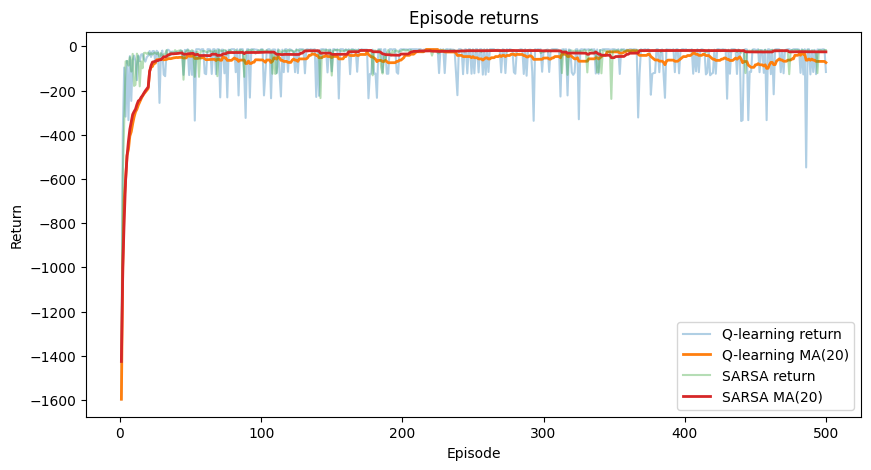

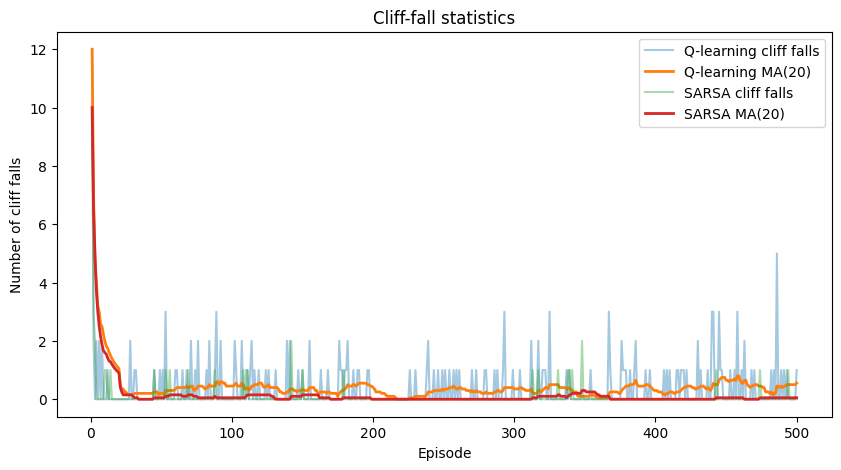

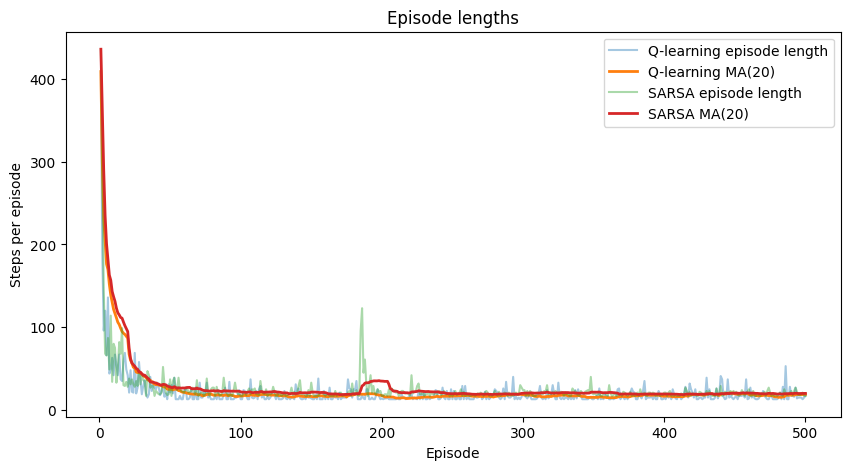

In [10]:
plot_training_curves(q_results, sarsa_results, window=20)


## 9. Numerical summary

This cell gives a compact quantitative comparison.


In [11]:
def summarize_results(name: str, results: dict, tail: int = 50):
    avg_return_all = np.mean(results["episode_returns"])
    avg_return_tail = np.mean(results["episode_returns"][-tail:])
    avg_length_tail = np.mean(results["episode_lengths"][-tail:])
    avg_falls_all = np.mean(results["cliff_falls"])
    avg_falls_tail = np.mean(results["cliff_falls"][-tail:])

    print(f"{name}")
    print("-" * len(name))
    print(f"Average return over all episodes:      {avg_return_all:.2f}")
    print(f"Average return over last {tail}:        {avg_return_tail:.2f}")
    print(f"Average episode length over last {tail}: {avg_length_tail:.2f}")
    print(f"Average cliff falls over all episodes: {avg_falls_all:.2f}")
    print(f"Average cliff falls over last {tail}:   {avg_falls_tail:.2f}")
    print()


summarize_results("Q-learning", q_results)
summarize_results("SARSA", sarsa_results)


Q-learning
----------
Average return over all episodes:      -57.10
Average return over last 50:        -59.12
Average episode length over last 50: 17.54
Average cliff falls over all episodes: 0.37
Average cliff falls over last 50:   0.42

SARSA
-----
Average return over all episodes:      -32.80
Average return over last 50:        -23.78
Average episode length over last 50: 19.82
Average cliff falls over all episodes: 0.08
Average cliff falls over last 50:   0.04



## 10. Suggested interpretation

Typical interpretation of the results:

- **Q-learning** is **off-policy**.  
  It updates toward the value of the best next action, regardless of whether the current behavior policy is still exploratory.

- **SARSA** is **on-policy**.  
  It updates using the next action actually selected by the current policy, including exploratory moves.

### Why that matters here

Near the cliff, exploratory mistakes are costly. Because SARSA learns values under the actual exploratory policy, it often internalizes that danger and prefers a safer route. Q-learning often converges toward the shorter greedy path near the cliff because it evaluates actions as if future control were fully greedy.

That is the core lesson of cliff walking: **the target of learning affects the learned behavior**.


## 11. Exercises

1. Increase `epsilon` and observe how the learned SARSA policy changes.
2. Reduce the cliff penalty from `-100` to `-20`. What happens?
3. Increase the grid size.
4. Add a heatmap of state visit counts.
5. Run multiple random seeds and average the curves.
6. Compare training with decaying epsilon versus fixed epsilon.
